# Support Vector Machines

- can perform linear or non-linear classification
- works on small-to-medium datasets well, but don't scale to very large datasets

- `large margin classification` is when two class instances are far away from each other 

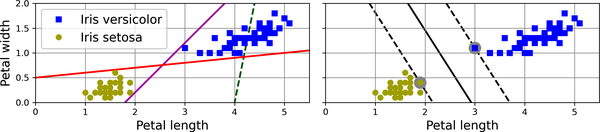

- when using SVM, it is better to have wide street between two decision boundaries is better 
- because if street is too small, later if outliers overlap with opposite class instances, model crashes 
- sometimes `StandartScaler` helps to widen the space between two decision boundaries of instances

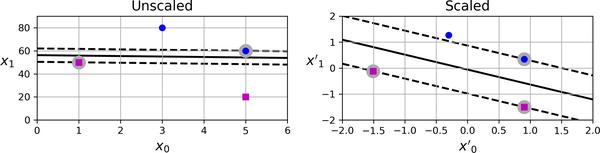

- SVM model complexity can be controller using the hyperpparameters such as `C`
- If model is overfitting we reduce the value of `C`, otherwise increase
- First image shows overfitted model and second with `C=100` showing decent generalization

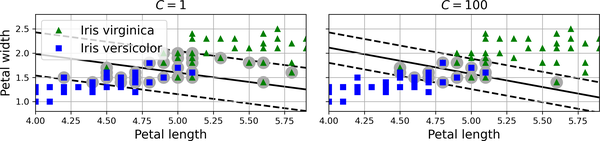

## Linear SVM

In [1]:
from sklearn.datasets import load_iris
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

iris = load_iris(as_frame=True)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 2)  # Iris virginica




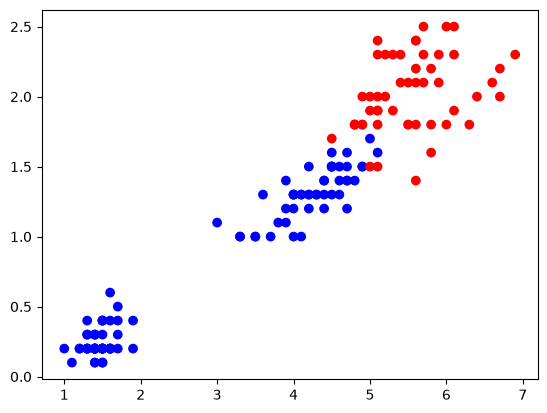

In [2]:
import matplotlib.pyplot as plt

# Convert Booleans to 1s and 0s
colors = [int(val) for val in y]

plt.scatter(X[:, 0], X[:, 1], c=colors, cmap="bwr", vmin=0, vmax=1)

In [3]:


svm_clf = make_pipeline(
    StandardScaler(),
    LinearSVC(C=100, random_state=42)
)   
svm_clf.fit(X, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('linearsvc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [4]:
X_new = [[5.5, 1.7], [5.0, 1.5]]
svm_clf.predict(X_new)

array([ True, False])

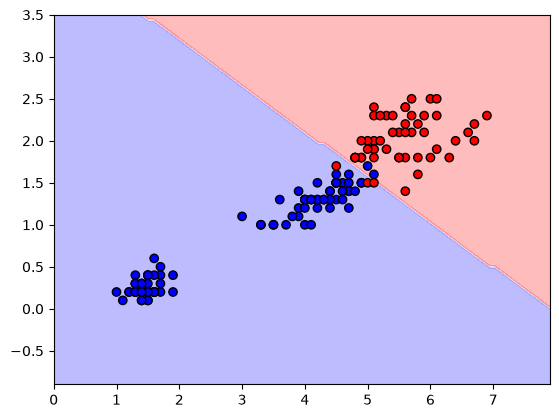

In [5]:
from sklearn.inspection import DecisionBoundaryDisplay

DecisionBoundaryDisplay.from_estimator(
    svm_clf, X, response_method="predict", cmap="bwr", alpha=0.3
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
plt.show()

In [6]:
svm_clf.decision_function(X_new)

array([ 1.27064191, -0.22916017])

## Non-Linear SVM Classification

- many datasets are not even close to being linearly separable: add polynomial features to make linearly separable dataset

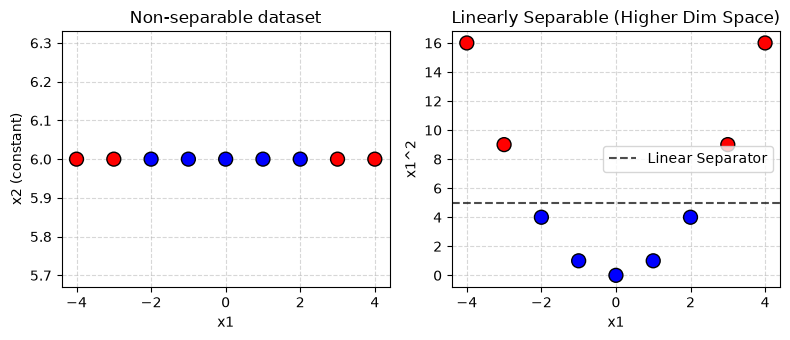

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

# 1. Create the DataFrame
df = pd.DataFrame({
   "x1": np.arange(-4, 5),
   "x2": [6] * 9,
   "y": (np.abs(np.arange(-4, 5)) > 2)
})

# FIX 1: Reference df["y"] correctly to build the color mapping array
colors = [int(val) for val in df["y"]]

# 2. Setup the side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))

# Plot 1: Original non-separable 1D/2D dataset
ax1.scatter(df["x1"], df["x2"], c=colors, cmap="bwr", s=100, edgecolors='k', zorder=3)
ax1.set_title("Non-separable dataset")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2 (constant)")
ax1.grid(True, linestyle="--", alpha=0.5)

# 3. Apply polynomial transformation (degree=2 by default)
poly = PolynomialFeatures()
pol_df = poly.fit_transform(df[["x1", "x2"]])

# FIX 2: Dynamic feature mapping for plotting
# pol_df[:, 1] corresponds to 'x1'
# pol_df[:, 3] corresponds to 'x1^2'
x1_transformed = pol_df[:, 1]
x1_squared = pol_df[:, 3]

# Plot 2: Project data into higher-dimensional space where it's separable
ax2.scatter(x1_transformed, x1_squared, c=colors, cmap="bwr", s=100, edgecolors='k', zorder=3)

# Draw a visual linear decision boundary line showing complete separation
ax2.axhline(y=5, color="black", linestyle="--", alpha=0.7, label="Linear Separator")

ax2.set_title("Linearly Separable (Higher Dim Space)")
ax2.set_xlabel("x1")
ax2.set_ylabel("x1^2")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()


- seen from thhe plots, if we use correclt ploynomial features we can make dataset linearly separable which enables us to use `LinearSVC` model to fit it

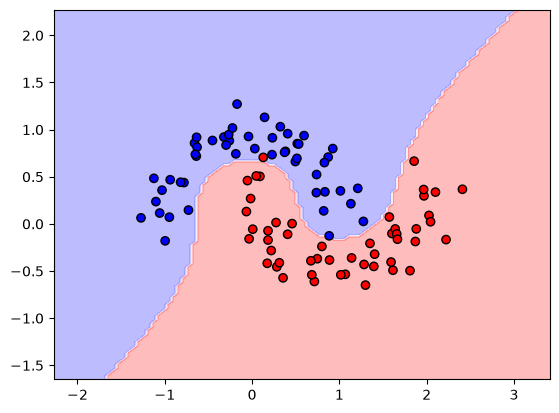

In [8]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearSVC(C=10, max_iter=10_000, random_state=42)
)
polynomial_svm_clf.fit(X, y)

from sklearn.inspection import DecisionBoundaryDisplay

DecisionBoundaryDisplay.from_estimator(
    polynomial_svm_clf, X, response_method="predict", cmap="bwr", alpha=0.3
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
plt.show()

In [70]:
from sklearn.svm import SVC

poly_kernel_svm_clf = make_pipeline(StandardScaler(),
                                    SVC(kernel="poly", degree=3, coef0=1, C=5))
poly_kernel_svm_clf.fit(X, y)

poly_kernel_svm_clf2 = make_pipeline(StandardScaler(),
                                    SVC(kernel="poly", degree=3, coef0=100, C=5))
poly_kernel_svm_clf2.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['alcohol','malic_acid','ash',...,'hue','od280/od315_of_diluted_wines', 'proline']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


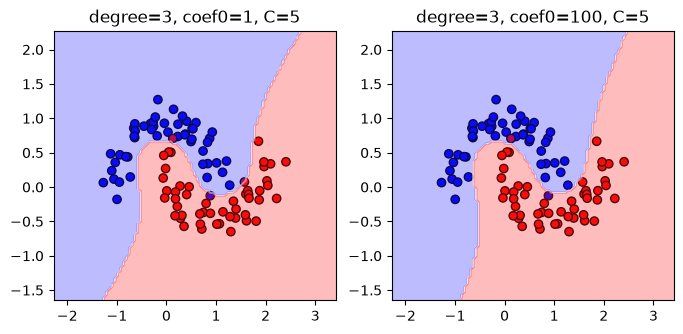

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))

ax1.set_title("degree=3, coef0=1, C=5")
ax2.set_title("degree=3, coef0=100, C=5")

ax1.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
ax2.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")

DecisionBoundaryDisplay.from_estimator(
    poly_kernel_svm_clf, X, response_method="predict", cmap="bwr", alpha=0.3,
    ax=ax1
)
DecisionBoundaryDisplay.from_estimator(
    poly_kernel_svm_clf2, X, response_method="predict", cmap="bwr", alpha=0.3,
    ax=ax2
)


## Gaussian RBF Kernel

- Like in `PolynomialFeatures` RBF kernel algorithm makes new features using pairs of each original features of training set
- As a result, the number of features will be equal to the number of all samples. 
- To avoid problems with large training sets, using cross-validation is important because the number of samples will be reduced as they split into folds, reducing  the number of rbf-generated features 
- there are two main hyperparameters of the `SVC(kernel='rbf')`: in `C` changes the margin width to increase the accuracy by exluding samlples out of the street while the `γ` (gamma) tries to fit model based on each indivial samples making the decision boundary more wavy and complex
- both of hypermarametrs can result in underfitting and overfitting, thus tuning should be done carefully

In [11]:
from sklearn.svm import SVC

rbf_kernel_svm_clf = make_pipeline(StandardScaler(),
                                    SVC(kernel="rbf", C=5, gamma=0.2))
rbf_kernel_svm_clf.fit(X, y)

rbf_kernel_svm_clf2 = make_pipeline(StandardScaler(),
                                    SVC(kernel="rbf", C=5, gamma=0.7))
rbf_kernel_svm_clf2.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


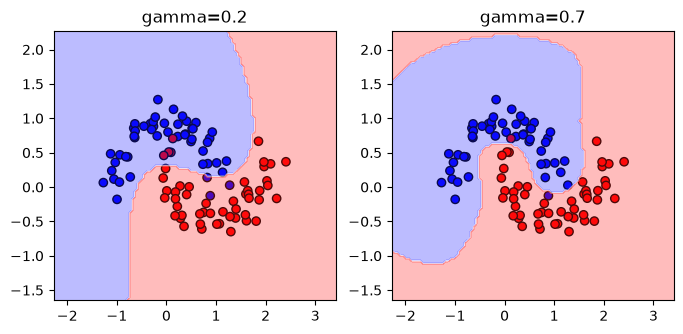

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))

ax1.set_title("gamma=0.2")
ax2.set_title("gamma=0.7")

ax1.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
ax2.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")

DecisionBoundaryDisplay.from_estimator(
    rbf_kernel_svm_clf, X, response_method="predict", cmap="bwr", alpha=0.3,
    ax=ax1
)
DecisionBoundaryDisplay.from_estimator(
    rbf_kernel_svm_clf2, X, response_method="predict", cmap="bwr", alpha=0.3,
    ax=ax2
)


## Choosing right SVM model

- first always try a `LinearSVC` after making dataset linearrly separable because it is the fastest approach to experiment
- don't use `SVC(kernel='linear')` instead use `LinearSVC`
- while tuning try to use optimized hp ranges
- then we can try different alogrithms 

## Computational Complexity

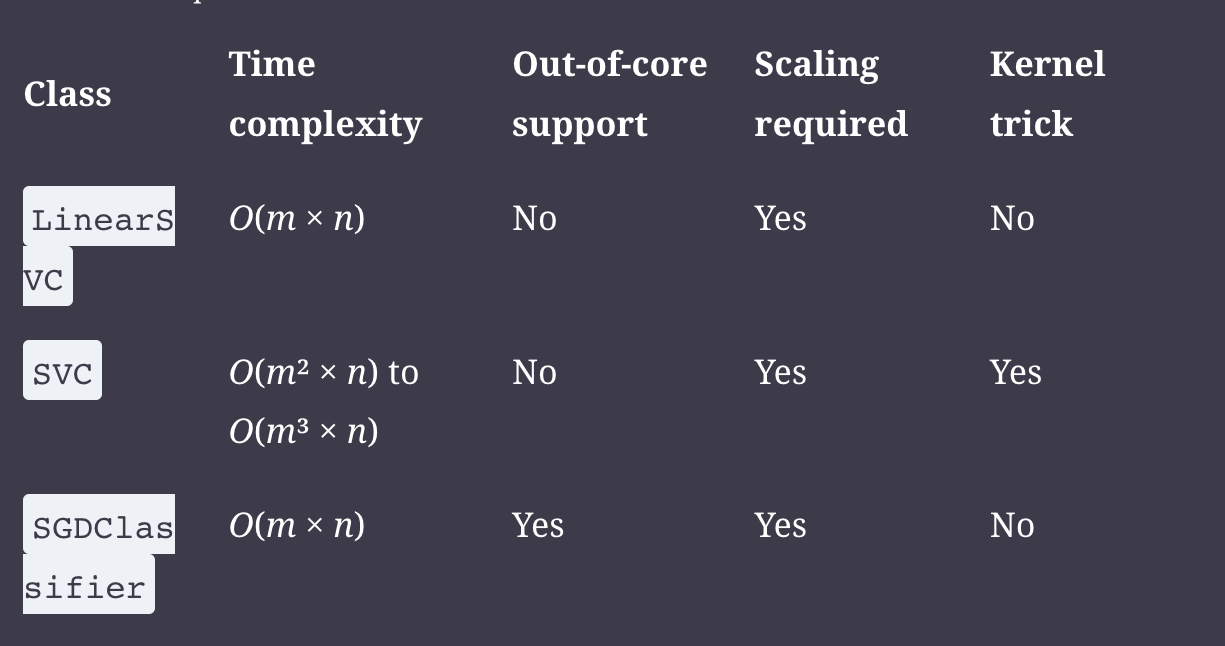

## SVM Regression

- Epsilon defines the width of the margin/street
- Margin in SVM regression serves opposite goal that instances in the margin are generalized by the model outlier are excluded 
- So adding more instances inside margin would not affect predicions at all, thus, the model is said to be ϵ-insensitive.
- `LinearSVC` => `LinearSVR`, and, `SVC` => `SVR`


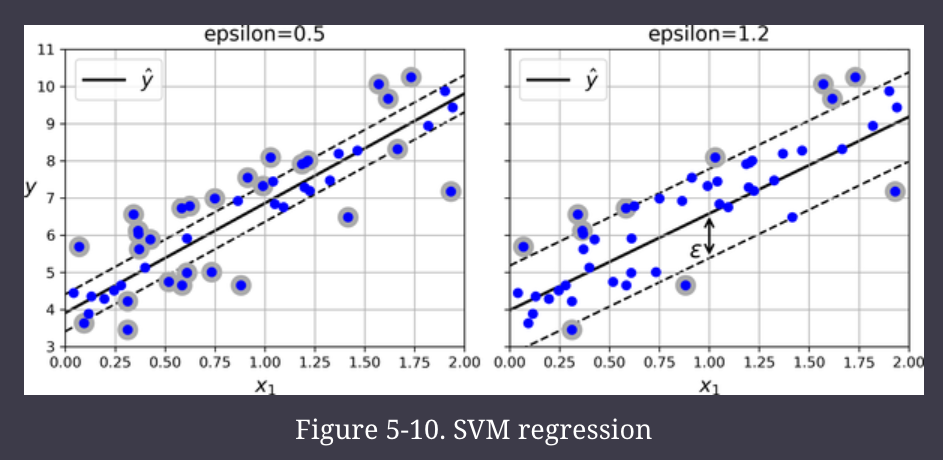

## Exercises

### 9. Train a LinearSVC on a linearly separable dataset. Then train an SVC and a SGDClassifier on the same dataset. See if you can get them to produce roughly the same model

In [4]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=6000,
    n_features=2,
    n_classes=4,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2.0,
    random_state=42
)

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,  y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score


models = {
    "lin_svc": LinearSVC(),
    "poly_svc": SVC(C=0.5, degree=4, kernel="rbf"),
    "sgd_clf": SGDClassifier(),
    
}

for title in models.keys():
    model = models[title]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(title, f": {acc:.3f}", )

lin_svc : 0.965
poly_svc : 0.972
sgd_clf : 0.973


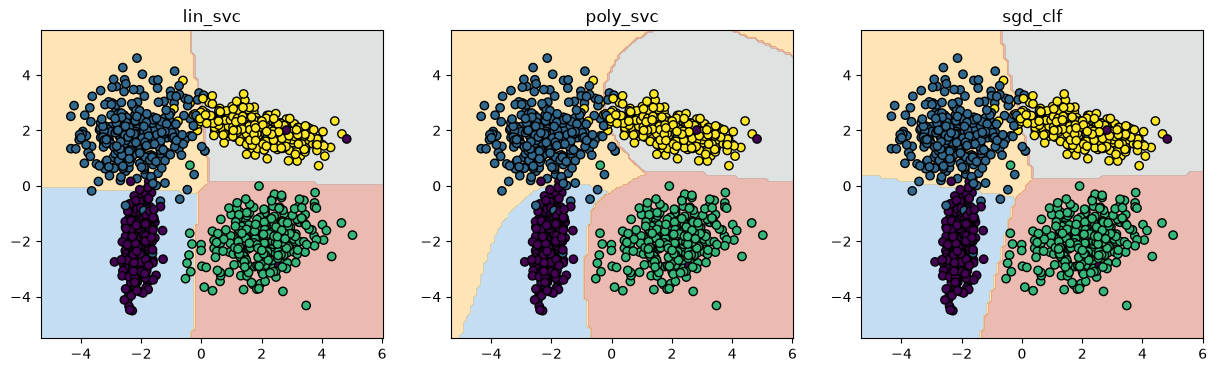

In [41]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
i = 0

for title in models.keys():
    model = models[title]

    DecisionBoundaryDisplay.from_estimator(
        model, X_test, response_method="predict", alpha=0.3, ax=axes[i]
    ) 
    axes[i].scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors="k")
    axes[i].set_title(title)
    
    i += 1


plt.show()

### Ex 10

Train an SVM classifier on the wine dataset, which you can load using sklearn.datasets.load_wine(). This dataset contains the chemical analyses of 178 wine samples produced by 3 different cultivators: the goal is to train a classification model capable of predicting the cultivator based on the wine’s chemical analysis. Since SVM classifiers are binary classifiers, you will need to use one-versus-all to classify all three classes. What accuracy can you reach?

In [3]:
from sklearn.datasets import load_wine
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [4]:
X, y = load_wine(as_frame=True, return_X_y=True)
X.shape

(178, 13)

In [3]:
lin_cv = cross_val_score(LinearSVC(random_state=42, dual=True, max_iter=1_000_000), X, y, cv=5, scoring="accuracy")
lin_cv.mean()

/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Li

np.float64(0.9442857142857143)

In [5]:
lin_scaled = make_pipeline(
    StandardScaler(),
    LinearSVC(C=0.7, dual=True, random_state=42)
)

lin_scaled_cv = cross_val_score(lin_scaled, X, y, cv=5, scoring="accuracy")
lin_scaled_cv.mean()

np.float64(0.9776190476190475)

In [6]:
svm_clf = make_pipeline(StandardScaler(), SVC(random_state=42))
cross_val_score(svm_clf, X, y).mean()

np.float64(0.9833333333333334)

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

param_distrib = {
    "svc__gamma": loguniform(0.001, 0.1),
    "svc__C": uniform(1, 10)
}
rnd_search_cv = RandomizedSearchCV(svm_clf, param_distrib, n_iter=100, cv=5,
                                   random_state=42)
rnd_search_cv.fit(X, y)
rnd_search_cv.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['alcohol','malic_acid','ash',...,'hue','od280/od315_of_diluted_wines', 'proline']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [8]:
rnd_search_cv.best_score_

np.float64(0.9888888888888889)

#### 11. Train and fine-tune an SVM regressor on the California housing dataset. You can use the original dataset rather than the tweaked version we used in Chapter 2, which you can load using sklearn.datasets.fetch_california_housing(). The targets represent hundreds of thousands of dollars. Since there are over 20,000 instances, SVMs can be slow, so for hyperparameter tuning you should use far fewer instances (e.g., 2,000) to test many more hyperparameter combinations. What is your best model’s RMSE?

In [1]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

print(housing.DESCR)


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(housing.data, housing.target, random_state=42)

In [3]:
X_train.shape

(15480, 8)

In [4]:
X_train[0]

array([   4.2143    ,   37.        ,    5.28823529,    0.97352941,
        860.        ,    2.52941176,   33.81      , -118.12      ])

In [15]:

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, LinearSVR

svm_lin = LinearSVR(epsilon=0.5, C=0.5, random_state=42, max_iter=10000)

svm_lin_pipe = make_pipeline(
    StandardScaler(),
    svm_lin
)

svm_rbf = SVR(kernel="rbf", gamma=0.3)

svm_rbf_pipe = make_pipeline(
    StandardScaler(),
    svm_rbf
)


models = {
    "svm_lin": svm_lin,
    "svm_lin_pipe": svm_lin_pipe,
    "svm_rbf": svm_rbf,
    "svm_rbf_pipe": svm_rbf_pipe,
}


In [16]:
for title in models.keys():
    model = models[title]
    cv = cross_val_score(model, X_train, y_train, scoring="neg_root_mean_squared_error", cv=10, n_jobs=-1)
    print("Mean Err for ", title, "is ",  cv.mean())


/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/yusufaxmad/Documents/ai/learning/ML-learning/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Li

Mean Err for  svm_lin is  -1.5308274327944165
Mean Err for  svm_lin_pipe is  -1.1136767553575107
Mean Err for  svm_rbf is  -1.1417537234193709
Mean Err for  svm_rbf_pipe is  -0.5723867735370997


#### Fine-Tuning with Randomized Search

In [28]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

svm_reg = make_pipeline(StandardScaler(), SVR())

param_distrib = {
    "svr__gamma": loguniform(0.001, 0.1),
    "svr__C": uniform(1, 10)
}

rnd_search_cv = RandomizedSearchCV(svm_reg, param_distrib, n_iter=100, cv=3, random_state=42)
rnd_search_cv.fit(X_train[:2000], y_train[:2000])

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svr__C': <scipy.stats....t 0x116f152d0>, 'svr__gamma': <scipy.stats....t 0x11604b530>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attribute

In [19]:
rnd_search_cv.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](8,)","[ 3.87, 29.04, 5.41,..., 2.92, 35.59,-119.55]"


In [20]:
from sklearn.metrics import root_mean_squared_error
y_pred = rnd_search_cv.best_estimator_.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
rmse

0.5782817381319515